# Overview
Ventricula ML is a deep learning project focused on the automated detection and classification of cardiac arrhythmias from electrocardiogram (ECG) signals. Using the MIT-BIH Arrhythmia and PTB Diagnostic ECG datasets, the system processes raw one-dimensional ECG recordings and identifies different heartbeat patterns, including normal rhythms and clinically significant abnormalities.

The project involves preprocessing and normalizing biological time-series data, designing and training neural network models to learn complex patterns from ECG signals, and addressing challenges such as class imbalance commonly found in medical datasets. The ultimate goal is to assist in the accurate recognition of cardiac conditions by distinguishing between normal heart activity and arrhythmic events such as ventricular and supraventricular ectopic beats.


In [1]:
# Imports and data loading phase I
import os
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
print("Downloading dataset...")
path = kagglehub.dataset_download("shayanfazeli/heartbeat")
print("Dataset downloaded to:", path)

# paths
train_path = os.path.join(path, "mitbih_train.csv")
test_path = os.path.join(path, "mitbih_test.csv")

# explicitly stating there are no header rows
print("\nLoading datasets into Pandas DataFrames...")
df_train = pd.read_csv(train_path, header=None)
df_test = pd.read_csv(test_path, header=None)

# structural shapes
print(f"Train Matrix Shape: {df_train.shape}")
print(f"Test Matrix Shape:  {df_test.shape}")

# quick peek at the first 5 rows
df_train.head()

Using Colab cache for faster access to the 'heartbeat' dataset.
Dataset downloaded to: /kaggle/input/heartbeat

Loading datasets into Pandas DataFrames...
Train Matrix Shape: (87554, 188)
Test Matrix Shape:  (21892, 188)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Phase II : Exploratory Data Analysis[EDA]

--- Class Distribution ---
Class 0 (Normal Beat (N)): 72471 samples (82.77%)
Class 1 (Supraventricular Premature (S)): 2223 samples (2.54%)
Class 2 (Premature Ventricular Contraction (V)): 5788 samples (6.61%)
Class 3 (Fusion Beat (F)): 641 samples (0.73%)
Class 4 (Unclassifiable Beat (Q)): 6431 samples (7.35%)


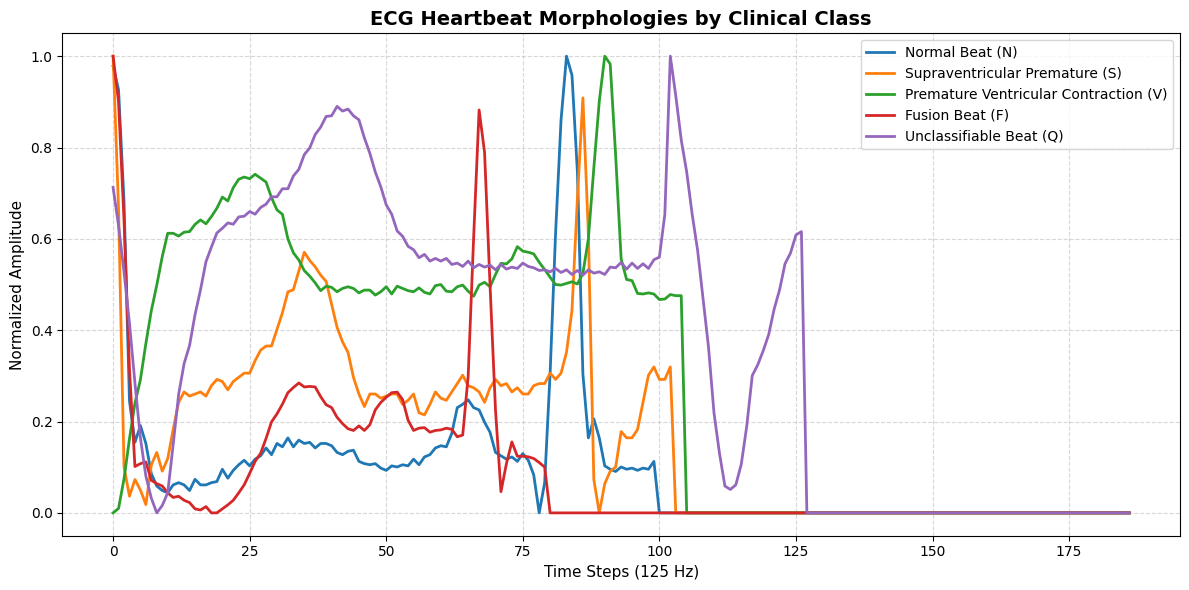

In [3]:
# labels in accordance to their medical definitions
class_map = {
    0: "Normal Beat (N)",
    1: "Supraventricular Premature (S)",
    2: "Premature Ventricular Contraction (V)",
    3: "Fusion Beat (F)",
    4: "Unclassifiable Beat (Q)"
 }

# class imbalance check
print("--- Class Distribution ---")
distribution = df_train[187].value_counts().sort_index()
for label, count in distribution.items():
    print(f"Class {int(label)} ({class_map[int(label)]}): {count} samples ({count/len(df_train)*100:.2f}%)")

# plot a representative heartbeat from each category
plt.figure(figsize=(12, 6))

for label in sorted(df_train[187].unique()):
    # first occurrence of each class
    sample_signal = df_train[df_train[187] == label].iloc[0, :-1]
    plt.plot(sample_signal, label=class_map[int(label)], linewidth=2)

plt.title("ECG Heartbeat Morphologies by Clinical Class", fontsize=14, fontweight="bold")
plt.xlabel("Time Steps (125 Hz)", fontsize=11)
plt.ylabel("Normalized Amplitude", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.show()

## Phase III: Data Preprocessing & Balancing

In [4]:
from sklearn.utils import resample
from tensorflow.keras.utils import to_categorical
print("Balancing the dataset...")

# the dataframe by class
df_0 = df_train[df_train[187] == 0]
df_1 = df_train[df_train[187] == 1]
df_2 = df_train[df_train[187] == 2]
df_3 = df_train[df_train[187] == 3]
df_4 = df_train[df_train[187] == 4]

# all classes have exactly 20,000 samples each
n_samples = 20000

df_0_bal = resample(df_0, replace=False, n_samples=n_samples, random_state=42) # Downsample
df_1_bal = resample(df_1, replace=True, n_samples=n_samples, random_state=42)  # Upsample
df_2_bal = resample(df_2, replace=True, n_samples=n_samples, random_state=42)  # Upsample
df_3_bal = resample(df_3, replace=True, n_samples=n_samples, random_state=42)  # Upsample
df_4_bal = resample(df_4, replace=True, n_samples=n_samples, random_state=42)  # Upsample

# combine and shuffle the new balanced dataset
df_balanced = pd.concat([df_0_bal, df_1_bal, df_2_bal, df_3_bal, df_4_bal])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# extract Features (X) and Labels (y)
X_train = df_balanced.iloc[:, :-1].values
y_train = df_balanced.iloc[:, -1].values

X_test = df_test.iloc[:, :-1].values
y_test = df_test.iloc[:, -1].values

# reshape X for 1D-CNN (Samples, Time Steps, Channels)
X_train = X_train.reshape(len(X_train), X_train.shape[1], 1)
X_test = X_test.reshape(len(X_test), X_test.shape[1], 1)

# one-hot encode the labels (e.g., Class 2 becomes [0, 0, 1, 0, 0])
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print(f"New X_train shape: {X_train.shape}")
print(f"New y_train shape: {y_train.shape}")
print("\nDataset is now perfectly balanced and reshaped for Deep Learning!")

Balancing the dataset...
New X_train shape: (100000, 187, 1)
New y_train shape: (100000, 5)

Dataset is now perfectly balanced and reshaped for Deep Learning!


# Phase IV: Model

In [ ]:
# Imports
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

In [ ]:
# 1D CNN ARCH
model = Sequential()

model.add(Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(187, 1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(Conv1D(filters=256, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(5, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# I/O
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 183, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 183, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 91, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 89, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 89, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 44, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 42, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 42, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 21, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       688,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 814,341 (3.11 MB)

 Trainable params: 813,445 (3.10 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# Training the model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 217s 68ms/step - accuracy: 0.8740 - loss: 0.3591 - val_accuracy: 0.8832 - val_loss: 0.2902
Epoch 2/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 214s 69ms/step - accuracy: 0.9375 - loss: 0.1708 - val_accuracy: 0.9323 - val_loss: 0.1790
Epoch 3/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 221s 71ms/step - accuracy: 0.9576 - loss: 0.1209 - val_accuracy: 0.9652 - val_loss: 0.1273
Epoch 4/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 213s 68ms/step - accuracy: 0.9659 - loss: 0.0961 - val_accuracy: 0.9663 - val_loss: 0.1337
Epoch 5/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 212s 68ms/step - accuracy: 0.9707 - loss: 0.0834 - val_accuracy: 0.9546 - val_loss: 0.1599
Epoch 6/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 265s 69ms/step - accuracy: 0.9757 - loss: 0.0702 - val_accuracy: 0.9495 - val_loss: 0.1696
Epoch 7/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 215s 69ms/step - accuracy: 0.9794 - loss: 0.0636 - val_accuracy: 0.9695 - val_loss: 0.1469
Epoch 8/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 257s 67ms/step - accuracy: 

In [5]:
# save model
from tensorflow.keras.models import load_model
from google.colab import drive
import shutil
import os

model_filename = 'Ventricula_ML_Final.keras'

model.save(model_filename)
print(f"Model saved locally as {model_filename}")

print("Connecting to Google Drive...")
drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/Ventricula_Models'

if not os.path.exists(drive_path):
    os.makedirs(drive_path)
destination = os.path.join(drive_path, model_filename)
shutil.copy(model_filename, destination)

print(f"Backup complete! Your model is at: {destination}")

NameError: name 'model' is not defined

NameError: name 'history' is not defined

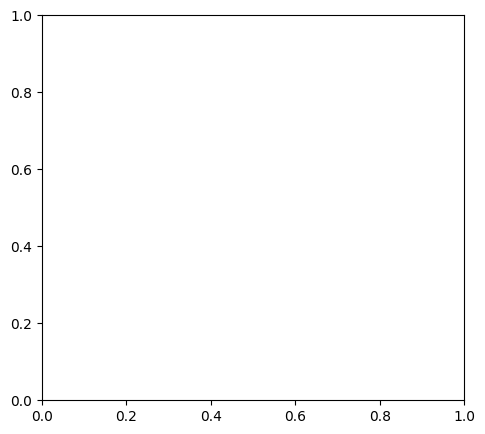

In [6]:
# Visualizing the training process and evaluation of the model for further analysis
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy over 20 Epochs', fontweight='bold')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss over 20 Epochs', fontweight='bold')
plt.ylabel('Loss (Categorical Crossentropy)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

print("Running predictions on the Test set...")
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_map.values(),
            yticklabels=class_map.values())
plt.title("Ventricula ML: Clinical Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted AI State", fontsize=12)
plt.ylabel("Actual Clinical State", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Running predictions on the Test set...


NameError: name 'model' is not defined

In [8]:
# Loading the model
from google.colab import drive
from tensorflow.keras.models import load_model

drive.mount('/content/drive')

print("Loading Ventricula ML...")
model = load_model('/content/drive/MyDrive/Ventricula_Models/Ventricula_ML_Final.keras')
print("Model successfully loaded into memory! Ready for inference.")

Mounted at /content/drive
Loading Ventricula ML...
Model successfully loaded into memory! Ready for inference.


In [9]:
# Inference
import numpy as np

In [10]:
class_map = {
    0: "Normal Beat (N)",
    1: "Supraventricular Premature (S)",
    2: "Premature Ventricular Contraction (V)",
    3: "Fusion Beat (F)",
    4: "Unclassifiable Beat (Q)"
}

In [11]:
def run_diagnostic(signal_array, true_label=None):
    """Feeds a single 1D ECG array to the model and prints the diagnosis."""
    prediction_probs = model.predict(signal_array, verbose=0)

    predicted_class = np.argmax(prediction_probs)
    confidence = np.max(prediction_probs) * 100

    print("\n" + "="*30)
    print("      DIAGNOSTIC REPORT      ")
    print("="*30)
    if true_label is not None:
        print(f"ACTUAL TRUTH: Class {true_label} ({class_map[true_label]})")

    print(f"AI DIAGNOSIS: Class {predicted_class} ({class_map[predicted_class]})")
    print(f"CONFIDENCE:   {confidence:.2f}%")
    print("="*30)

# Test
random_index = 42
sample_heartbeat = X_test[random_index].reshape(1, 187, 1)
actual_truth = np.argmax(y_test[random_index])

run_diagnostic(sample_heartbeat, actual_truth)


      DIAGNOSTIC REPORT      
ACTUAL TRUTH: Class 0 (Normal Beat (N))
AI DIAGNOSIS: Class 0 (Normal Beat (N))
CONFIDENCE:   100.00%


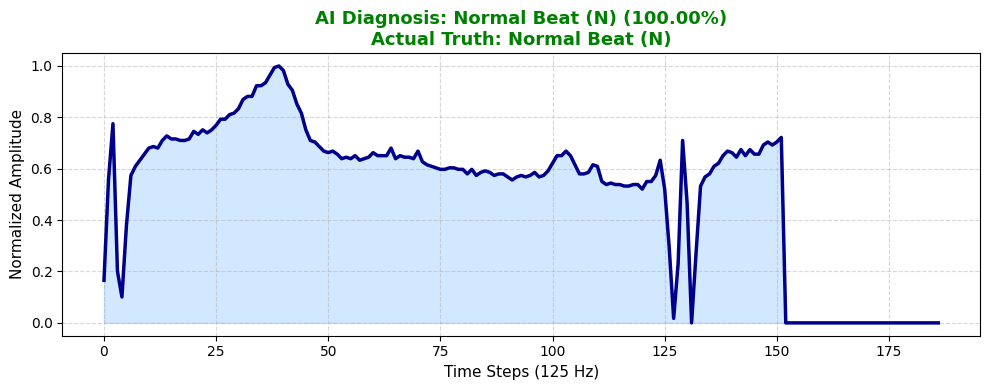

In [12]:
import matplotlib.pyplot as plt

def visual_diagnostic(signal_array, true_label=None):
    """Feeds an ECG array to the model and plots the heartbeat with the AI's diagnosis."""
    prediction_probs = model.predict(signal_array, verbose=0)
    predicted_class = np.argmax(prediction_probs)
    confidence = np.max(prediction_probs) * 100

    flat_signal = signal_array.flatten()

    plt.figure(figsize=(10, 4))
    plt.plot(flat_signal, color='darkblue', linewidth=2.5)

    if true_label is not None:
        text_color = 'green' if predicted_class == true_label else 'red'
        truth_text = f"\nActual Truth: {class_map[true_label]}"
    else:
        text_color = 'black'
        truth_text = ""

    plt.title(f"AI Diagnosis: {class_map[predicted_class]} ({confidence:.2f}%){truth_text}",
              color=text_color, fontweight='bold', fontsize=13)

    plt.xlabel("Time Steps (125 Hz)", fontsize=11)
    plt.ylabel("Normalized Amplitude", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.fill_between(range(len(flat_signal)), flat_signal, alpha=0.2, color='dodgerblue')

    plt.tight_layout()
    plt.show()

test_index = 42
sample_beat = X_test[test_index].reshape(1, 187, 1)
true_label = np.argmax(y_test[test_index])

visual_diagnostic(sample_beat, true_label)

Target Acquired! Found a Class 2 arrhythmia at index: 18674



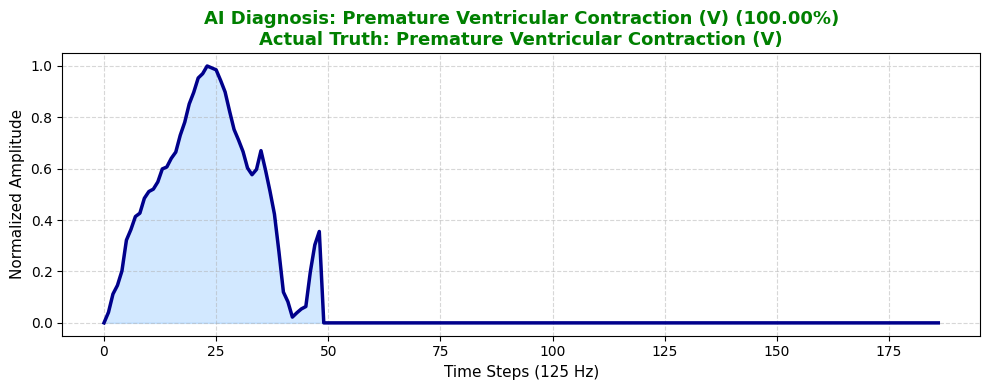

In [13]:
import numpy as np

target_anomaly_class = 2

true_classes = np.argmax(y_test, axis=1)

anomaly_indices = np.where(true_classes == target_anomaly_class)[0]

if len(anomaly_indices) > 0:
    test_index = anomaly_indices[0]
    print(f"Target Acquired! Found a Class {target_anomaly_class} arrhythmia at index: {test_index}\n")

    sample_beat = X_test[test_index].reshape(1, 187, 1)
    true_label = true_classes[test_index]

    visual_diagnostic(sample_beat, true_label)
else:
    print(f"Could not find any Class {target_anomaly_class} beats in this dataset.")